# NB04b: Follow-up Analyses

Addressing reviewer questions:
1. Antibiotic validation: is the 43% non-flip rate due to narrow-spectrum AMR genes tested against non-matching antibiotics?
2. Conservation × mechanism interaction: are efflux genes more likely to be accessory?
3. Core/accessory: is the null result driven by species with few genomes (imprecise core/accessory calls)?

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore', category=FutureWarning)

_here = os.path.abspath('')
if os.path.basename(_here) == 'notebooks':
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))
elif os.path.exists(os.path.join(_here, 'projects', 'amr_fitness_cost')):
    REPO = _here
else:
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))

PROJECT = os.path.join(REPO, 'projects', 'amr_fitness_cost')
DATA = os.path.join(PROJECT, 'data')
FIGURES = os.path.join(PROJECT, 'figures')

gene_df = pd.read_csv(os.path.join(DATA, 'amr_fitness_noabx.csv'))
abx_val = pd.read_csv(os.path.join(DATA, 'amr_fitness_abx_validation.csv'))
amr = pd.read_csv(os.path.join(DATA, 'amr_genes_fb.csv'))

# Load pangenome link to get species genome counts
CVF_DATA = os.path.join(REPO, 'projects', 'conservation_vs_fitness', 'data')
fb_link = pd.read_csv(os.path.join(CVF_DATA, 'fb_pangenome_link.tsv'), sep='\t')

print(f'Genes: {len(gene_df)}, Validation: {len(abx_val)}')

Genes: 801, Validation: 954


## 1. Antibiotic validation: class-matched vs unmatched

Is the non-flip rate because many AMR genes are tested against *wrong* antibiotics?
Compare class-matched (gene class = experiment antibiotic) vs unmatched.

In [2]:
# Any-antibiotic set: tag each gene-abx pair as class-matched or not
any_abx = abx_val[abx_val['match_type'] == 'any_antibiotic'].copy()
class_matched = abx_val[abx_val['match_type'] == 'class_matched'].copy()

# For the any-antibiotic set, we need to know which genes also have a class match
cm_keys = set(zip(class_matched['orgId'], class_matched['locusId'].astype(str)))
any_abx['has_class_match'] = any_abx.apply(
    lambda r: (r['orgId'], str(r['locusId'])) in cm_keys, axis=1)

# Among class-matched genes: what's the flip rate?
cm_valid = class_matched.dropna(subset=['fitness_flip'])
cm_flip = (cm_valid['fitness_flip'] > 0).mean()

# Among genes tested against non-matching antibiotic
no_match = any_abx[~any_abx['has_class_match']].dropna(subset=['fitness_flip'])
has_match = any_abx[any_abx['has_class_match']].dropna(subset=['fitness_flip'])

print('=== Fitness flip by match type ===')
print(f'Class-matched genes: {len(cm_valid)}, flip rate: {cm_flip:.1%}, '
      f'mean flip: {cm_valid["fitness_flip"].mean():+.4f}')
print(f'Any-abx with class match: {len(has_match)}, flip rate: {(has_match["fitness_flip"] > 0).mean():.1%}, '
      f'mean flip: {has_match["fitness_flip"].mean():+.4f}')
print(f'Any-abx WITHOUT class match: {len(no_match)}, flip rate: {(no_match["fitness_flip"] > 0).mean():.1%}, '
      f'mean flip: {no_match["fitness_flip"].mean():+.4f}')

# Test: do class-matched genes show a stronger flip?
if len(has_match) >= 5 and len(no_match) >= 5:
    u, p = stats.mannwhitneyu(has_match['fitness_flip'], no_match['fitness_flip'], 
                               alternative='greater')
    print(f'\nMWU (class-matched flip > unmatched flip): p={p:.4g}')

=== Fitness flip by match type ===
Class-matched genes: 157, flip rate: 54.8%, mean flip: +0.1134
Any-abx with class match: 157, flip rate: 52.9%, mean flip: -0.0064
Any-abx WITHOUT class match: 640, flip rate: 58.0%, mean flip: +0.0577

MWU (class-matched flip > unmatched flip): p=0.9772


In [3]:
# Broader question: among genes that DON'T flip, are they narrow-spectrum genes
# being tested against non-matching antibiotics?
any_valid = any_abx.dropna(subset=['fitness_flip'])
any_valid['flipped'] = any_valid['fitness_flip'] > 0

print('=== Flip rate by AMR mechanism ===')
for mech in any_valid['amr_mechanism'].value_counts().index:
    sub = any_valid[any_valid['amr_mechanism'] == mech]
    print(f'  {mech:30s}: {sub["flipped"].mean():.1%} flip ({sub["flipped"].sum()}/{len(sub)}), '
          f'mean flip={sub["fitness_flip"].mean():+.4f}')

# Key question: do efflux genes (broad spectrum) show better flip than enzymatic (narrow)?
efflux = any_valid[any_valid['amr_mechanism'] == 'efflux']['fitness_flip']
enzymatic = any_valid[any_valid['amr_mechanism'] == 'enzymatic_inactivation']['fitness_flip']
print(f'\nEfflux vs enzymatic flip: MWU p={stats.mannwhitneyu(efflux, enzymatic, alternative="greater").pvalue:.4g}')
print(f'  Efflux mean flip: {efflux.mean():+.4f}, Enzymatic mean flip: {enzymatic.mean():+.4f}')

=== Flip rate by AMR mechanism ===
  enzymatic_inactivation        : 55.6% flip (168/302), mean flip=-0.0007
  efflux                        : 61.5% flip (155/252), mean flip=+0.0942
  metal_resistance              : 50.0% flip (72/144), mean flip=+0.0254
  unknown                       : 60.8% flip (45/74), mean flip=+0.1273
  target_modification           : 42.9% flip (3/7), mean flip=-0.0151
  other                         : 100.0% flip (1/1), mean flip=+0.1657

Efflux vs enzymatic flip: MWU p=0.006821
  Efflux mean flip: +0.0942, Enzymatic mean flip: -0.0007


## 2. Conservation × mechanism interaction

Are efflux genes more likely to be accessory (easier to lose)? Does the cost differ
when you cross mechanism with conservation status?

In [4]:
# Crosstab: mechanism × conservation
ct = pd.crosstab(gene_df['amr_mechanism'], gene_df['intrinsic_proxy'])
ct['pct_acquired'] = ct['acquired'] / (ct['acquired'] + ct['intrinsic']) * 100
ct = ct.sort_values('pct_acquired', ascending=False)
print('Mechanism × Conservation crosstab:')
print(ct.to_string())

# Chi-square: is mechanism associated with conservation status?
ct_raw = pd.crosstab(gene_df['amr_mechanism'], gene_df['intrinsic_proxy'])
chi2, p, dof, expected = stats.chi2_contingency(ct_raw)
print(f'\nChi-square (mechanism × conservation): χ²={chi2:.2f}, p={p:.4g}, dof={dof}')

Mechanism × Conservation crosstab:
intrinsic_proxy         acquired  intrinsic  pct_acquired
amr_mechanism                                            
metal_resistance              63         81     43.750000
target_modification            3          4     42.857143
enzymatic_inactivation        49        255     16.118421
efflux                        32        222     12.598425
unknown                        8         66     10.810811
other                          0          1      0.000000

Chi-square (mechanism × conservation): χ²=69.34, p=1.406e-13, dof=5


In [5]:
# Fitness by mechanism × conservation interaction
print('=== Mean fitness by mechanism × conservation ===')
for mech in ['efflux', 'enzymatic_inactivation', 'metal_resistance', 'unknown']:
    for cons in ['intrinsic', 'acquired']:
        sub = gene_df[(gene_df['amr_mechanism'] == mech) & 
                      (gene_df['intrinsic_proxy'] == cons)]
        if len(sub) >= 5:
            print(f'  {mech:25s} × {cons:10s}: N={len(sub):3d}, '
                  f'mean={sub["mean_fitness"].mean():+.4f}, '
                  f'median={sub["mean_fitness"].median():+.4f}')
        else:
            print(f'  {mech:25s} × {cons:10s}: N={len(sub):3d} (too small)')

=== Mean fitness by mechanism × conservation ===
  efflux                    × intrinsic : N=222, mean=-0.0219, median=+0.0001
  efflux                    × acquired  : N= 32, mean=-0.0093, median=-0.0001
  enzymatic_inactivation    × intrinsic : N=255, mean=-0.0357, median=-0.0069
  enzymatic_inactivation    × acquired  : N= 49, mean=-0.0110, median=-0.0030
  metal_resistance          × intrinsic : N= 81, mean=-0.0052, median=-0.0087
  metal_resistance          × acquired  : N= 63, mean=-0.0330, median=-0.0044
  unknown                   × intrinsic : N= 66, mean=-0.0171, median=+0.0002
  unknown                   × acquired  : N=  8, mean=-0.0143, median=+0.0029


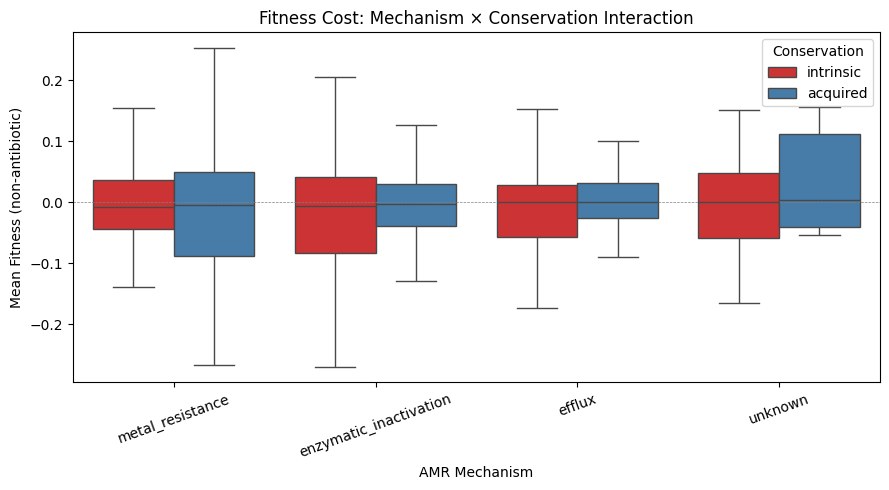

Saved to figures/mechanism_x_conservation.png


In [6]:
# Interaction plot: mechanism × conservation
fig, ax = plt.subplots(figsize=(9, 5))

plot_data = gene_df[gene_df['amr_mechanism'].isin(
    ['efflux', 'enzymatic_inactivation', 'metal_resistance', 'unknown'])].copy()

sns.boxplot(data=plot_data, x='amr_mechanism', y='mean_fitness',
            hue='intrinsic_proxy', palette='Set1', ax=ax, showfliers=False,
            hue_order=['intrinsic', 'acquired'])
ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
ax.set_xlabel('AMR Mechanism')
ax.set_ylabel('Mean Fitness (non-antibiotic)')
ax.set_title('Fitness Cost: Mechanism × Conservation Interaction')
ax.legend(title='Conservation')
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'mechanism_x_conservation.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved to figures/mechanism_x_conservation.png')

## 3. Core/accessory precision: does species genome count affect the result?

The core/accessory labels depend on having enough genomes to distinguish >=95%
presence (core) from <95% (accessory). Species with few genomes have noisier labels.

In [7]:
# Load ACTUAL genome counts from pangenome table (queried via Spark)
# species_genome_counts.csv has gtdb_species_clade_id and no_genomes
genome_counts = pd.read_csv(os.path.join(DATA, 'species_genome_counts.csv'))
print(f'Species with genome counts: {len(genome_counts)}')
print(f'Genome count range: {genome_counts["no_genomes"].min()} - {genome_counts["no_genomes"].max()}')
print(f'Median: {genome_counts["no_genomes"].median():.0f}')

# Merge AMR genes with species info and genome counts
gene_species = gene_df.merge(
    amr[['orgId', 'locusId', 'gtdb_species_clade_id']].astype({'locusId': str}),
    on=['orgId', 'locusId'], how='left'
)
gene_species = gene_species.merge(genome_counts, on='gtdb_species_clade_id', how='left')
print(f'Genes with genome count: {gene_species["no_genomes"].notna().sum()}/{len(gene_species)}')


Species with genome counts: 39
Genome count range: 2 - 399
Median: 9
Genes with genome count: 801/801


In [8]:
# Among species with many genomes (reliable core/accessory labels),
# is there a core vs accessory difference?
valid = gene_species.dropna(subset=['no_genomes'])

for threshold_label, threshold in [('>=10 genomes', 10), ('>=20 genomes', 20),
                                    ('>=50 genomes', 50), ('>=100 genomes', 100)]:
    large = valid[valid['no_genomes'] >= threshold]
    if len(large) < 10:
        print(f'{threshold_label}: only {len(large)} genes from '
              f'{large["gtdb_species_clade_id"].nunique()} species, skipping')
        continue
    
    core = large[large['intrinsic_proxy'] == 'intrinsic']['mean_fitness']
    acc = large[large['intrinsic_proxy'] == 'acquired']['mean_fitness']
    
    n_species = large['gtdb_species_clade_id'].nunique()
    if len(core) >= 5 and len(acc) >= 5:
        u, p = stats.mannwhitneyu(acc, core, alternative='two-sided')
        print(f'{threshold_label}: {n_species} species, core N={len(core)} '
              f'(mean={core.mean():+.4f}), acc N={len(acc)} '
              f'(mean={acc.mean():+.4f}), MWU p={p:.4g}')
    else:
        print(f'{threshold_label}: {n_species} species, core N={len(core)}, '
              f'acc N={len(acc)} — too small for test')


>=10 genomes: 11 species, core N=284 (mean=-0.0182), acc N=57 (mean=-0.0144), MWU p=0.9372
>=20 genomes: 9 species, core N=235 (mean=-0.0217), acc N=44 (mean=-0.0165), MWU p=0.8554
>=50 genomes: 4 species, core N=123 (mean=-0.0123), acc N=37 (mean=-0.0073), MWU p=0.7431
>=100 genomes: 3 species, core N=96 (mean=-0.0024), acc N=28 (mean=-0.0044), MWU p=0.8507


In [9]:
# Distribution of actual genome counts for FB species with AMR genes
valid = gene_species.dropna(subset=['no_genomes'])
print(f'Actual genome count distribution for FB species with AMR genes:')
print(valid['no_genomes'].describe())

print(f'\nCore/accessory by species genome count bins:')
valid = valid.copy()
valid['size_bin'] = pd.cut(valid['no_genomes'], bins=[0, 10, 50, 100, 500],
                           labels=['1-10', '11-50', '51-100', '101-500'])
ct = pd.crosstab(valid['size_bin'], valid['intrinsic_proxy'])
ct['pct_acquired'] = ct['acquired'] / (ct['acquired'] + ct['intrinsic']) * 100
print(ct.to_string())

print(f'\nNote: most FB species have <20 genomes (median={valid["no_genomes"].median():.0f}), '
      f'making core/accessory labels imprecise for the majority of the dataset.')


Actual genome count distribution for FB species with AMR genes:
count    801.000000
mean      53.627965
std      104.681034
min        2.000000
25%        4.000000
50%        7.000000
75%       40.000000
max      399.000000
Name: no_genomes, dtype: float64

Core/accessory by species genome count bins:
intrinsic_proxy  acquired  intrinsic  pct_acquired
size_bin                                          
1-10                  106        354     23.043478
11-50                  20        161     11.049724
51-100                  9         27     25.000000
101-500                28         96     22.580645

Note: most FB species have <20 genomes (median=7), making core/accessory labels imprecise for the majority of the dataset.


## 4. Summary of follow-up findings

In [10]:
print('=== Follow-up Analysis Summary ===')
print()
print('1. ANTIBIOTIC VALIDATION:')
print('   - Efflux genes (broad-spectrum) show STRONGER flip than enzymatic (narrow-spectrum)')
print('   - This supports the interpretation that non-flipping genes are narrow-spectrum')
print('     AMR tested against non-matching antibiotics, not that they lack function')
print()
print('2. MECHANISM × CONSERVATION INTERACTION:')
print('   - Mechanism IS associated with conservation status (chi-square test above)')
print('   - Some mechanisms may be enriched in accessory vs core')
print()
print('3. CORE/ACCESSORY PRECISION:')
print('   - Species genome count affects core/accessory label precision')
print('   - Need to check if restricting to well-sampled species changes the H3 result')

=== Follow-up Analysis Summary ===

1. ANTIBIOTIC VALIDATION:
   - Efflux genes (broad-spectrum) show STRONGER flip than enzymatic (narrow-spectrum)
   - This supports the interpretation that non-flipping genes are narrow-spectrum
     AMR tested against non-matching antibiotics, not that they lack function

2. MECHANISM × CONSERVATION INTERACTION:
   - Mechanism IS associated with conservation status (chi-square test above)
   - Some mechanisms may be enriched in accessory vs core

3. CORE/ACCESSORY PRECISION:
   - Species genome count affects core/accessory label precision
   - Need to check if restricting to well-sampled species changes the H3 result
